# PCA part
after: https://towardsdatascience.com/pca-using-python-scikit-learn-e653f8989e60

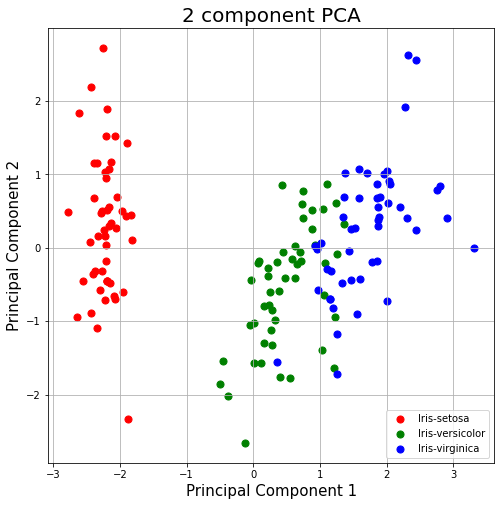

In [256]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"# load dataset into Pandas DataFrame
df = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])
features = ['sepal length', 'sepal width', 'petal length', 'petal width']
# Separating out the features
x = df.loc[:, features].values# Separating out the target
y = df.loc[:,['target']].values# Standardizing the features
x = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, df[['target']]], axis = 1)
finalDf
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()
#Variation explained
print(pca.explained_variance_ratio_)
np.sum(pca.explained_variance_ratio_)

## On the Centerline Dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [164]:
#path='/groups/zimmer/Ulises/code/skeleton_OLD/spline/second_der_np_new.csv'
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-10-48_control_worm1_spline_K.csv'
# has no reversals path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_18-17-47_chemotaxis_worm5_spline_K.csv'
df=pd.read_csv(path, header=None)

df.shape
df.dropna(inplace=True)
features = np.arange(20,99)# Separating out the features
x = df.loc[:, features].values
print(x.shape)

(137785, 79)


In [165]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(x)
principalComponents.shape
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2','PC3','PC4','PC5'])

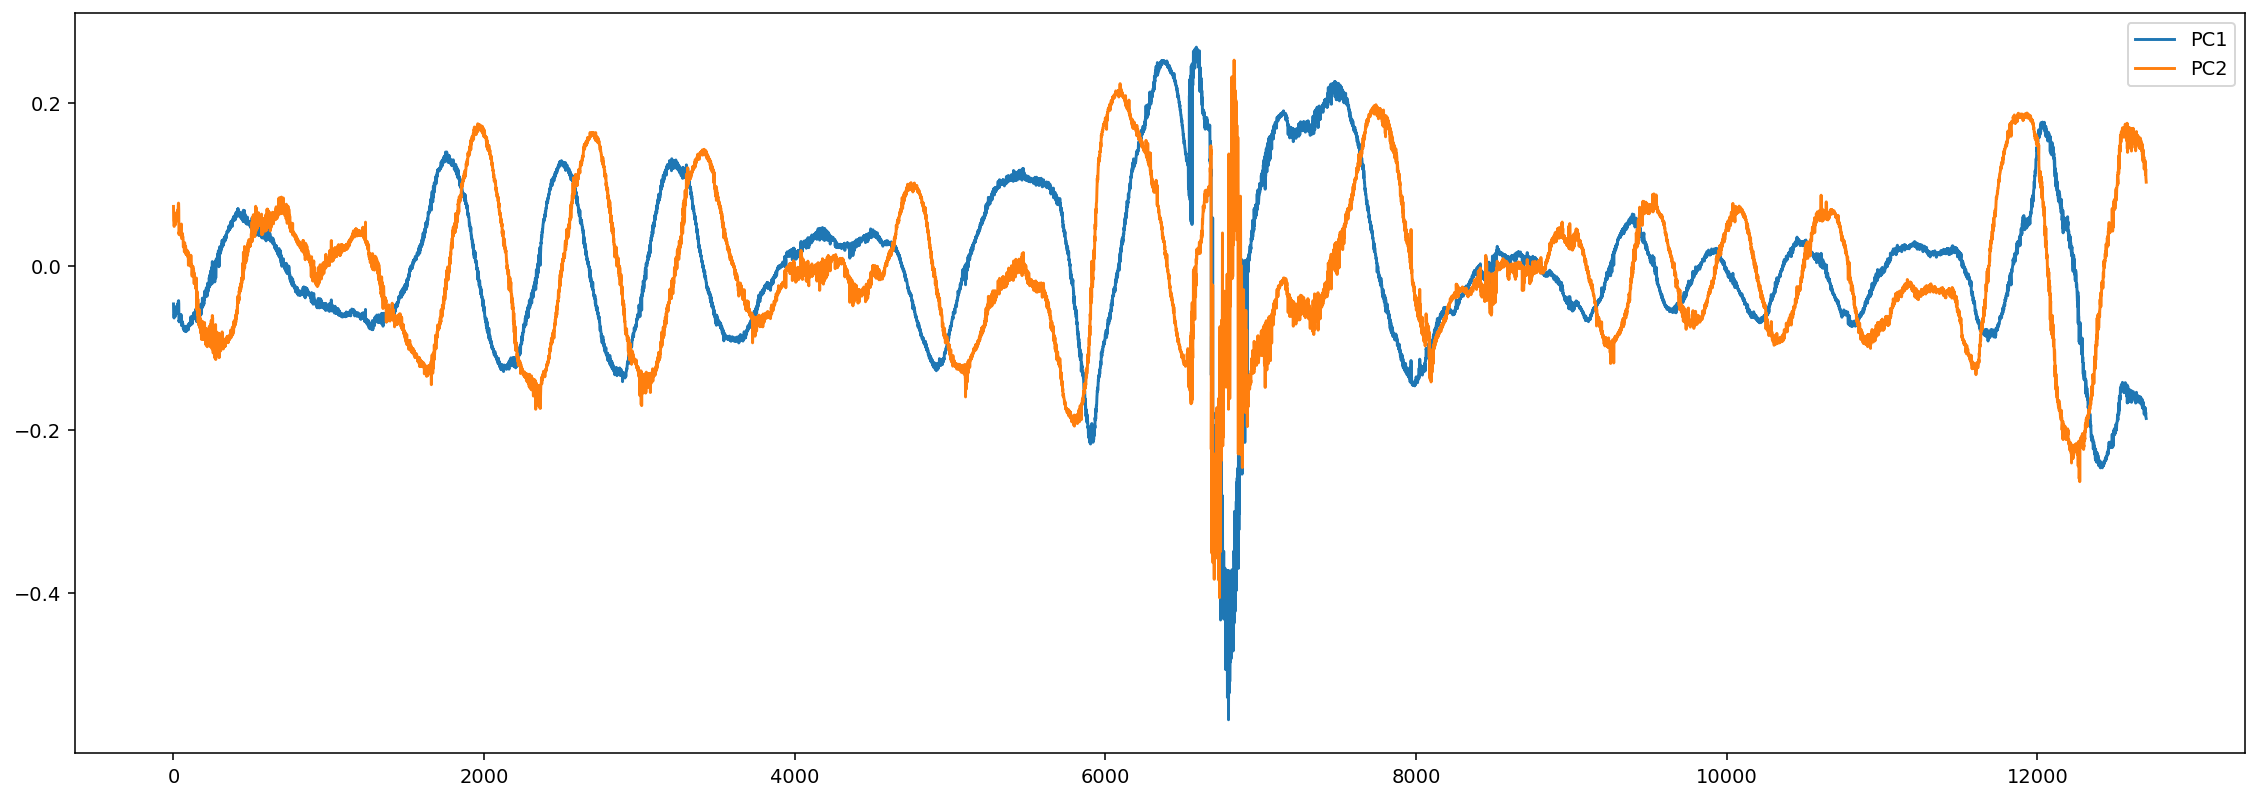

In [166]:
for pc in principalDf:
    if pc is 'PC3': break
    principalDf.loc[0:12700,pc].plot(legend=True, figsize=(20,7))

In [81]:
principalDf.head(10)
#pc1Xpc2=pd.DataFrame(np.cross(principalDf['PC1'],principalDf['PC2']), index=principalDf.index)

,PC1,PC2,PC3,PC4,PC5
0,-0.027982,-0.022547,0.084162,0.126246,0.005640
1,-0.069630,-0.033729,-0.015314,0.116307,0.039159
2,-0.071638,-0.034260,-0.020612,0.115209,0.046192
3,-0.075567,-0.032253,-0.024239,0.109849,0.048310
4,-0.078946,-0.034754,-0.038091,0.106453,0.049259
5,-0.064283,-0.023877,0.009369,0.113776,0.036473
6,-0.067092,-0.030608,-0.007552,0.112066,0.041962
7,-0.064234,-0.031249,-0.005323,0.112517,0.039783
8,-0.065672,-0.029183,-0.001440,0.108801,0.038011
9,-0.053325,-0.020987,0.042193,0.123293,0.034152


In [189]:
x.to_numpy()[0]

nan

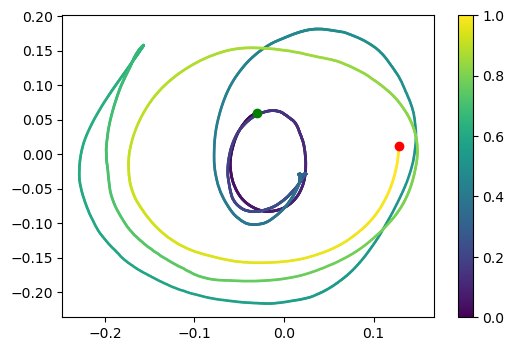

In [199]:
time=np.arange(10000,14000)
avg_win=150
x=principalDf.loc[time,'PC1'].rolling(window=avg_win).mean()
y=principalDf.loc[time,'PC2'].rolling(window=avg_win).mean()
plt.scatter(x,y, c=np.arange(len(x)), s=1, cmap='viridis')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')
plt.colorbar()

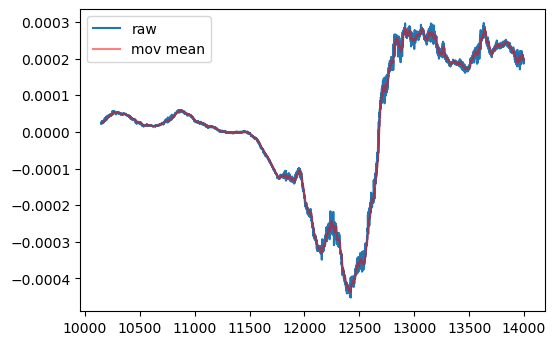

In [200]:
#create dataframe from series
frame = { 'X': x, 'Y': y } 
cross_product_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.nan]
for i, row in enumerate(cross_product_df.iterrows()):
    if i==len(cross_product_df)-1: continue
    r=np.cross([cross_product_df['X'].values[i],cross_product_df['Y'].values[i]], [cross_product_df['X'].values[i+1],cross_product_df['Y'].values[i+1]])
    
    ra.append(r)
cross_product_df['Cross Product']=ra

#optional plotting
plt.plot(cross_product_df.loc[:,'Cross Product'], label='raw')
plt.plot(cross_product_df.index, cross_product_df.loc[:,'Cross Product'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.legend()

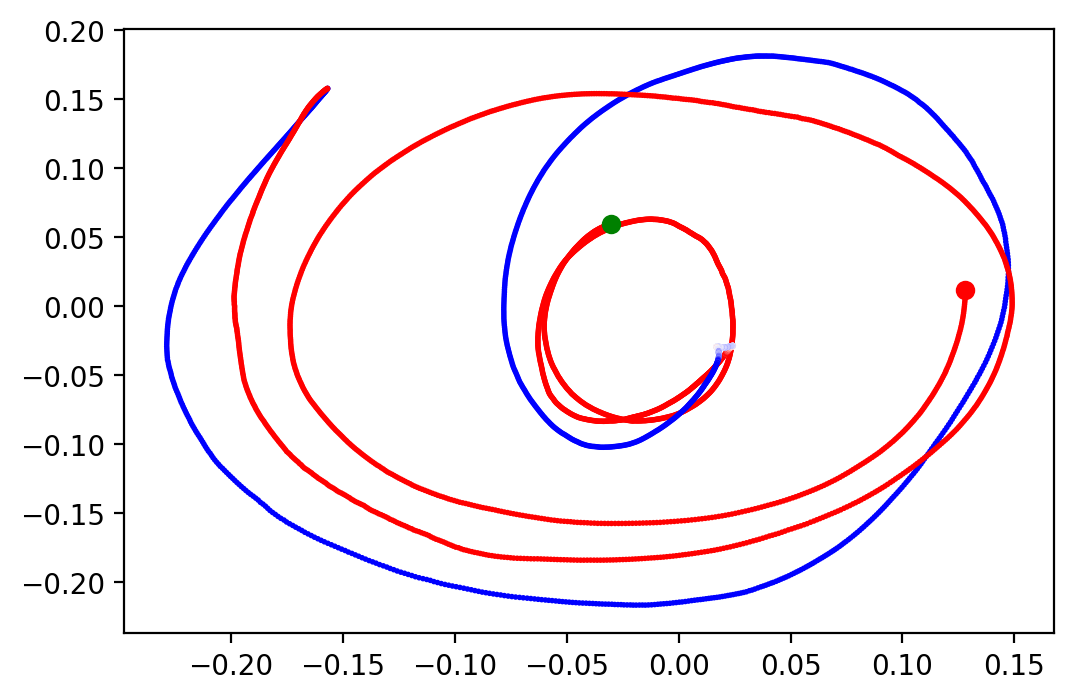

In [207]:
plt.figure(dpi=200)
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')

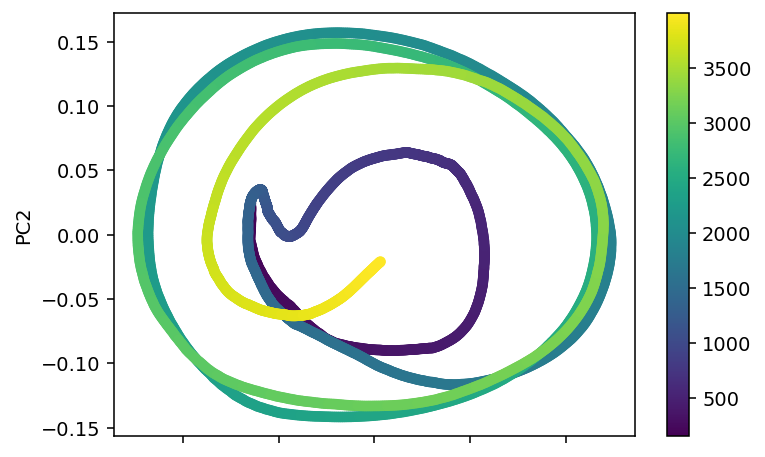

In [187]:
avg_principalDf=pd.DataFrame()
avg_win=150
avg_principalDf=principalDf.rolling(window=avg_win).mean()
x='PC1'
y='PC2'
t_range=np.arange(4000)
plt.rcParams["figure.dpi"] = 140
avg_principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c=t_range, colormap='viridis')#c=principalDf.index
#ax.set_xlabel('PC1')
#ax.show()
#ax.set_ylabel("y label")

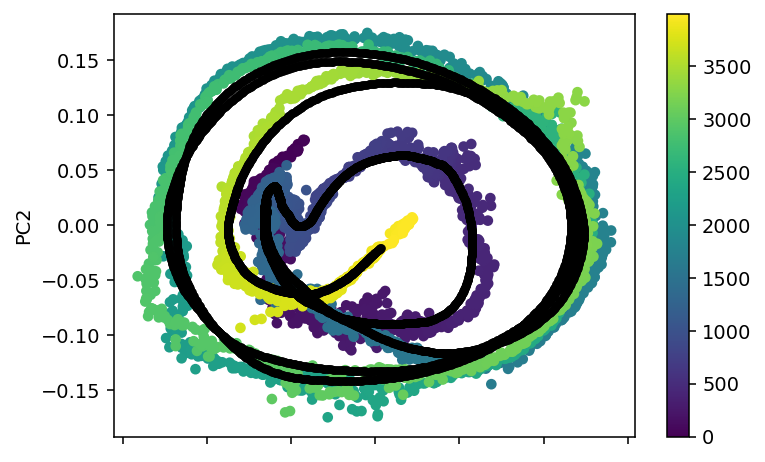

In [175]:
ax=principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c=t_range, colormap='viridis')#c=principalDf.index
avg_principalDf.loc[t_range,:].plot.scatter(x=x, y=y, c='k', ax=ax, linewidth=0.001)#c=principalDf.index

## Plot Eigenworms

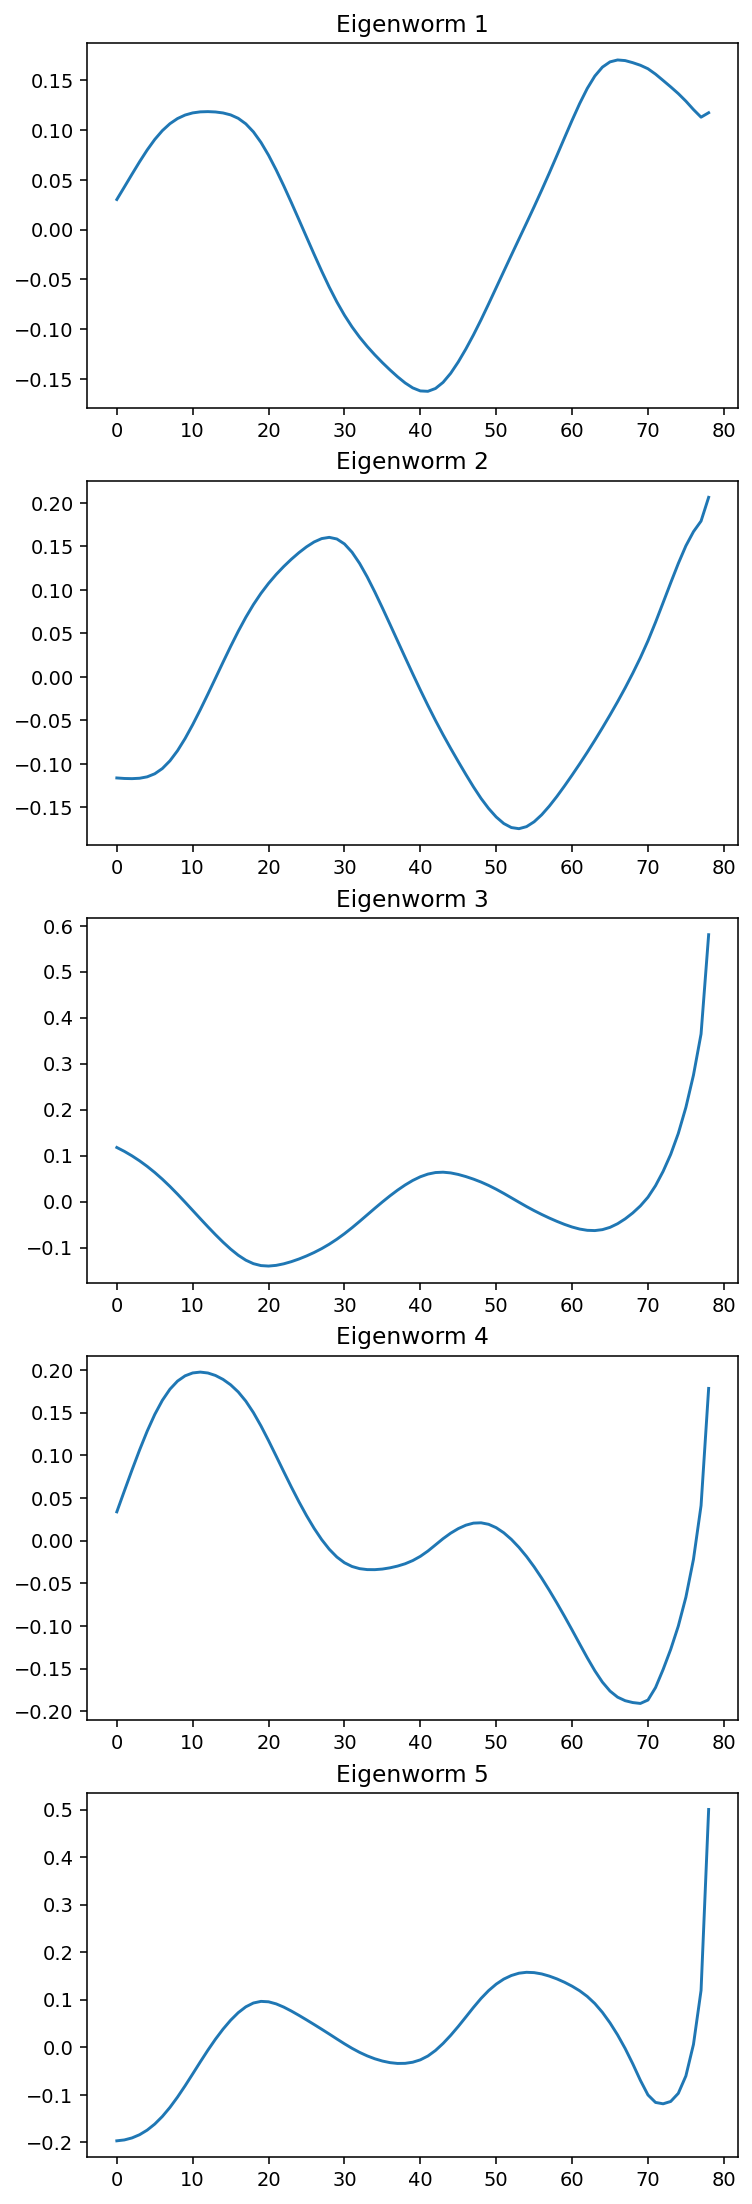

In [178]:
fig1, f1_axs = plt.subplots(ncols=1, nrows=5, constrained_layout=False, figsize=(6,20))
for i, eigenworm in enumerate(pca.components_):
    f1_axs[i].plot(eigenworm)
    f1_axs[i].set_title('Eigenworm ' +str(i+1))
#     f1_axs[0,i].set_xlabel('Time (frames)')
#     f1_axs[0,i].set_ylabel('Signal Amplitude (a.u)')
#         fig.plot(eigenworm)
#     .title('Eingenworm ' +str(i))
#     plt.show()
# i=i+1
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum())
# f1_axs[i].plot(pca.explained_variance_ratio_.cumsum(), 'bo')
# f1_axs[i].ylim([0,1])
# f1_axs[i].ylabel('Variance Explained')
# f1_axs[i].xlabel('PC')
# f1_axs[i].xticks(np.arange(5), principalDf.columns)

### Variance explained

[0.36040439 0.3026438  0.11356267 0.08805029 0.04879869]


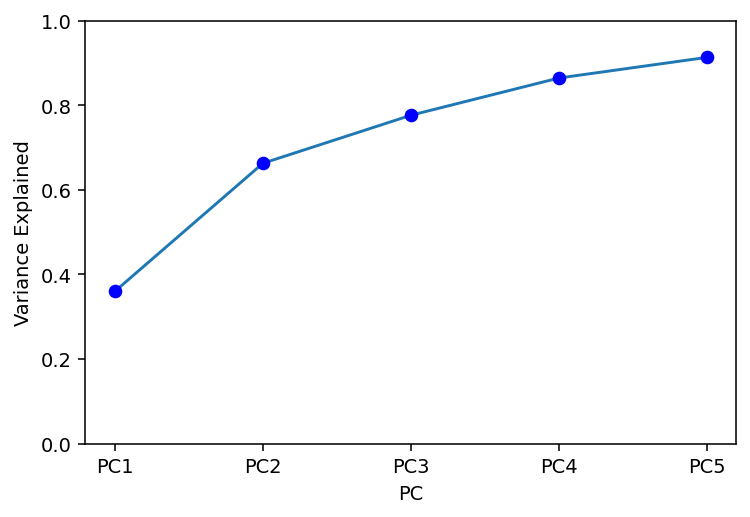

In [181]:
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.plot(pca.explained_variance_ratio_.cumsum(), 'bo')
plt.ylim([0,1])
plt.ylabel('Variance Explained')
plt.xlabel('PC')
plt.xticks(np.arange(5), principalDf.columns)
print(pca.explained_variance_ratio_)

In [182]:
first_pc_df=pd.DataFrame()
first_pc_df=avg_principalDf.drop(labels=['PC3', 'PC4', 'PC5'], axis=1)

In [156]:
first_pc_vector_df=first_pc_df.diff()
first_pc_vector_df=first_pc_vector_df.dropna()

In [159]:
ra=[]
for i, row in enumerate(first_pc_vector_df.iterrows()):
    r=np.cross([first_pc_vector_df['PC1'].values[i],first_pc_vector_df['PC2'].values[i]], [first_pc_vector_df['PC1'].values[i+1],first_pc_vector_df['PC2'].values[i+1]])
    #print(r)
    ra.append(r)
    if i==12700: break

(-1e-05, 1e-05)

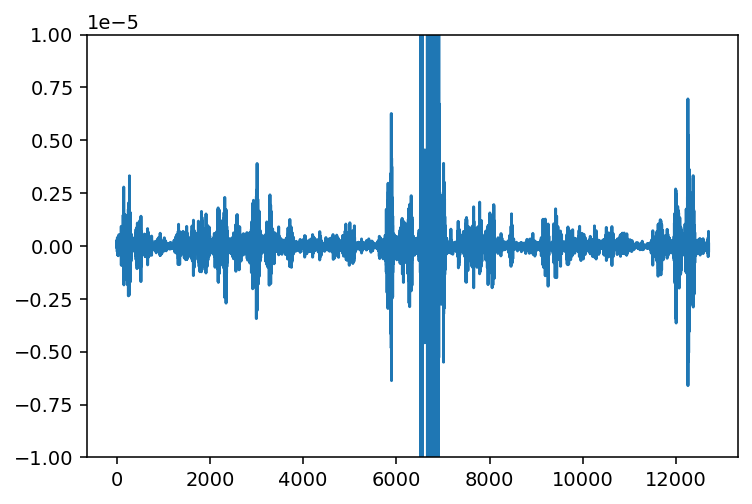

In [160]:
plt.plot(ra)
plt.ylim([-0.00001, 0.00001])

# For body segments

In [208]:
#path='/groups/zimmer/Ulises/code/skeleton_OLD/spline/second_der_np_new.csv'
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-10-48_control_worm1_spline_K.csv'
# has no reversals path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_18-17-47_chemotaxis_worm5_spline_K.csv'
df=pd.read_csv(path, header=None)

print(df.shape)
df.dropna(inplace=True)
print(df.shape)


plt.rcParams["figure.dpi"] = 100

(142465, 100)
(137785, 100)


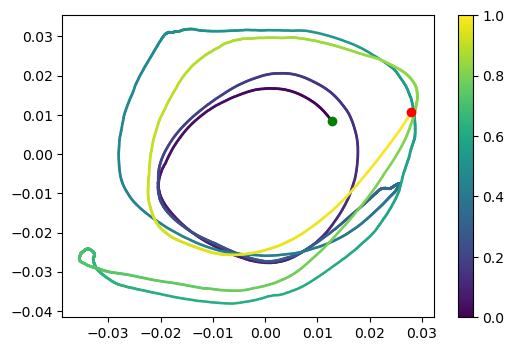

In [209]:
time=np.arange(10000,14000)#np.arange(30000,34000)
avg_win=150
x=df.loc[time,80].rolling(window=avg_win).mean()
y=df.loc[time,90].rolling(window=avg_win).mean()
# x.dropna(inplace=True)
# y.dropna(inplace=True)
plt.scatter(x,y, c=np.arange(len(x)), s=1, cmap='viridis')
plt.scatter(x.to_numpy()[avg_win+1],y.to_numpy()[avg_win+1], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')
plt.colorbar()

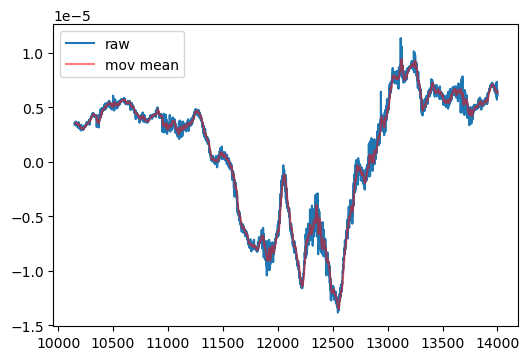

In [210]:
#create dataframe from series
frame = { 'X': x, 'Y': y } 
cross_product_df=pd.DataFrame(data=frame)#, columns=[80, 90])#columns=['80', '90'])

ra=[np.nan]
for i, row in enumerate(cross_product_df.iterrows()):
    if i==len(cross_product_df)-1: continue
    r=np.cross([cross_product_df['X'].values[i],cross_product_df['Y'].values[i]], [cross_product_df['X'].values[i+1],cross_product_df['Y'].values[i+1]])
    
    ra.append(r)
cross_product_df['Cross Product']=ra

#optional plotting
plt.plot(cross_product_df.loc[:,'Cross Product'], label='raw')
plt.plot(cross_product_df.index, cross_product_df.loc[:,'Cross Product'].rolling(window=10).mean(), alpha=.5, c='r', label='mov mean')
plt.legend()

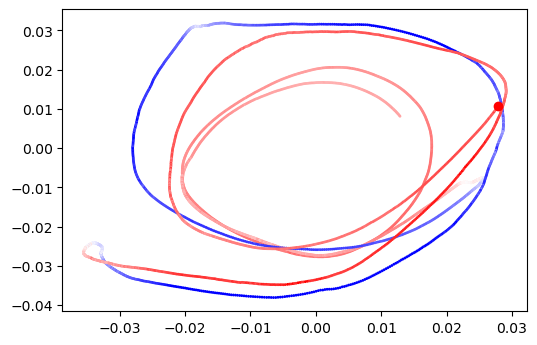

In [211]:
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[0],y.to_numpy()[0], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')

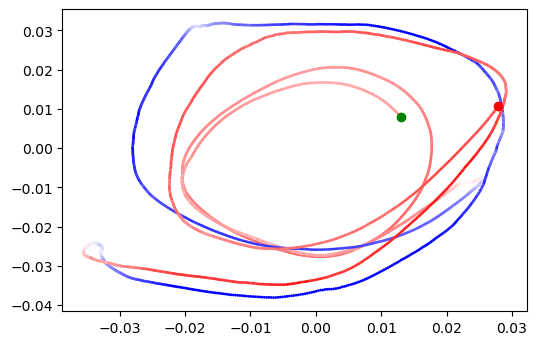

In [66]:
plt.scatter(x,y, c=cross_product_df.loc[:,'Cross Product'], vmin=-1e-5, vmax=1e-5, s=1, cmap='bwr')
plt.scatter(x.to_numpy()[0],y.to_numpy()[0], c='g')
plt.scatter(x.to_numpy()[-1],y.to_numpy()[-1], c='r')

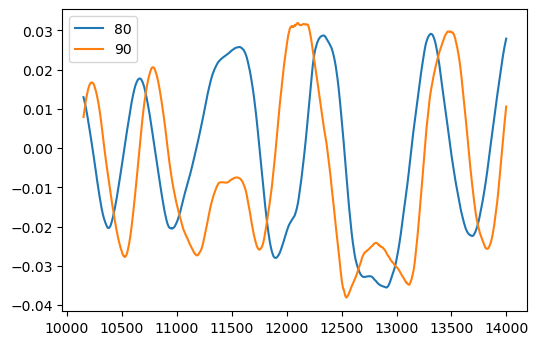

In [139]:
plt.plot(x, label='80')
plt.plot(y, label='90')
plt.legend()

## Plot track

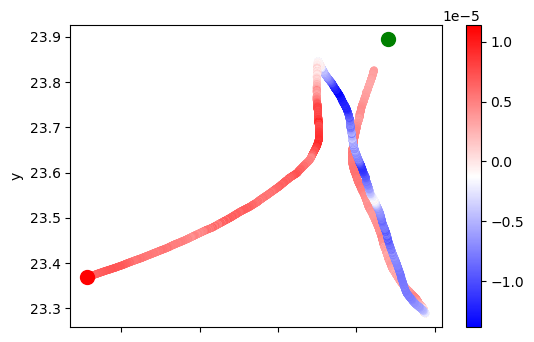

In [144]:
ax=track_df.plot.scatter(x='x', y='y', c=cross_product_df.loc[:,'Cross Product'], cmap='bwr')
ax.plot(track_df['x'].head(1),track_df['y'].head(1), 'go', markersize=10)
ax.plot(track_df['x'].tail(1),track_df['y'].tail(1), 'ro', markersize=10)

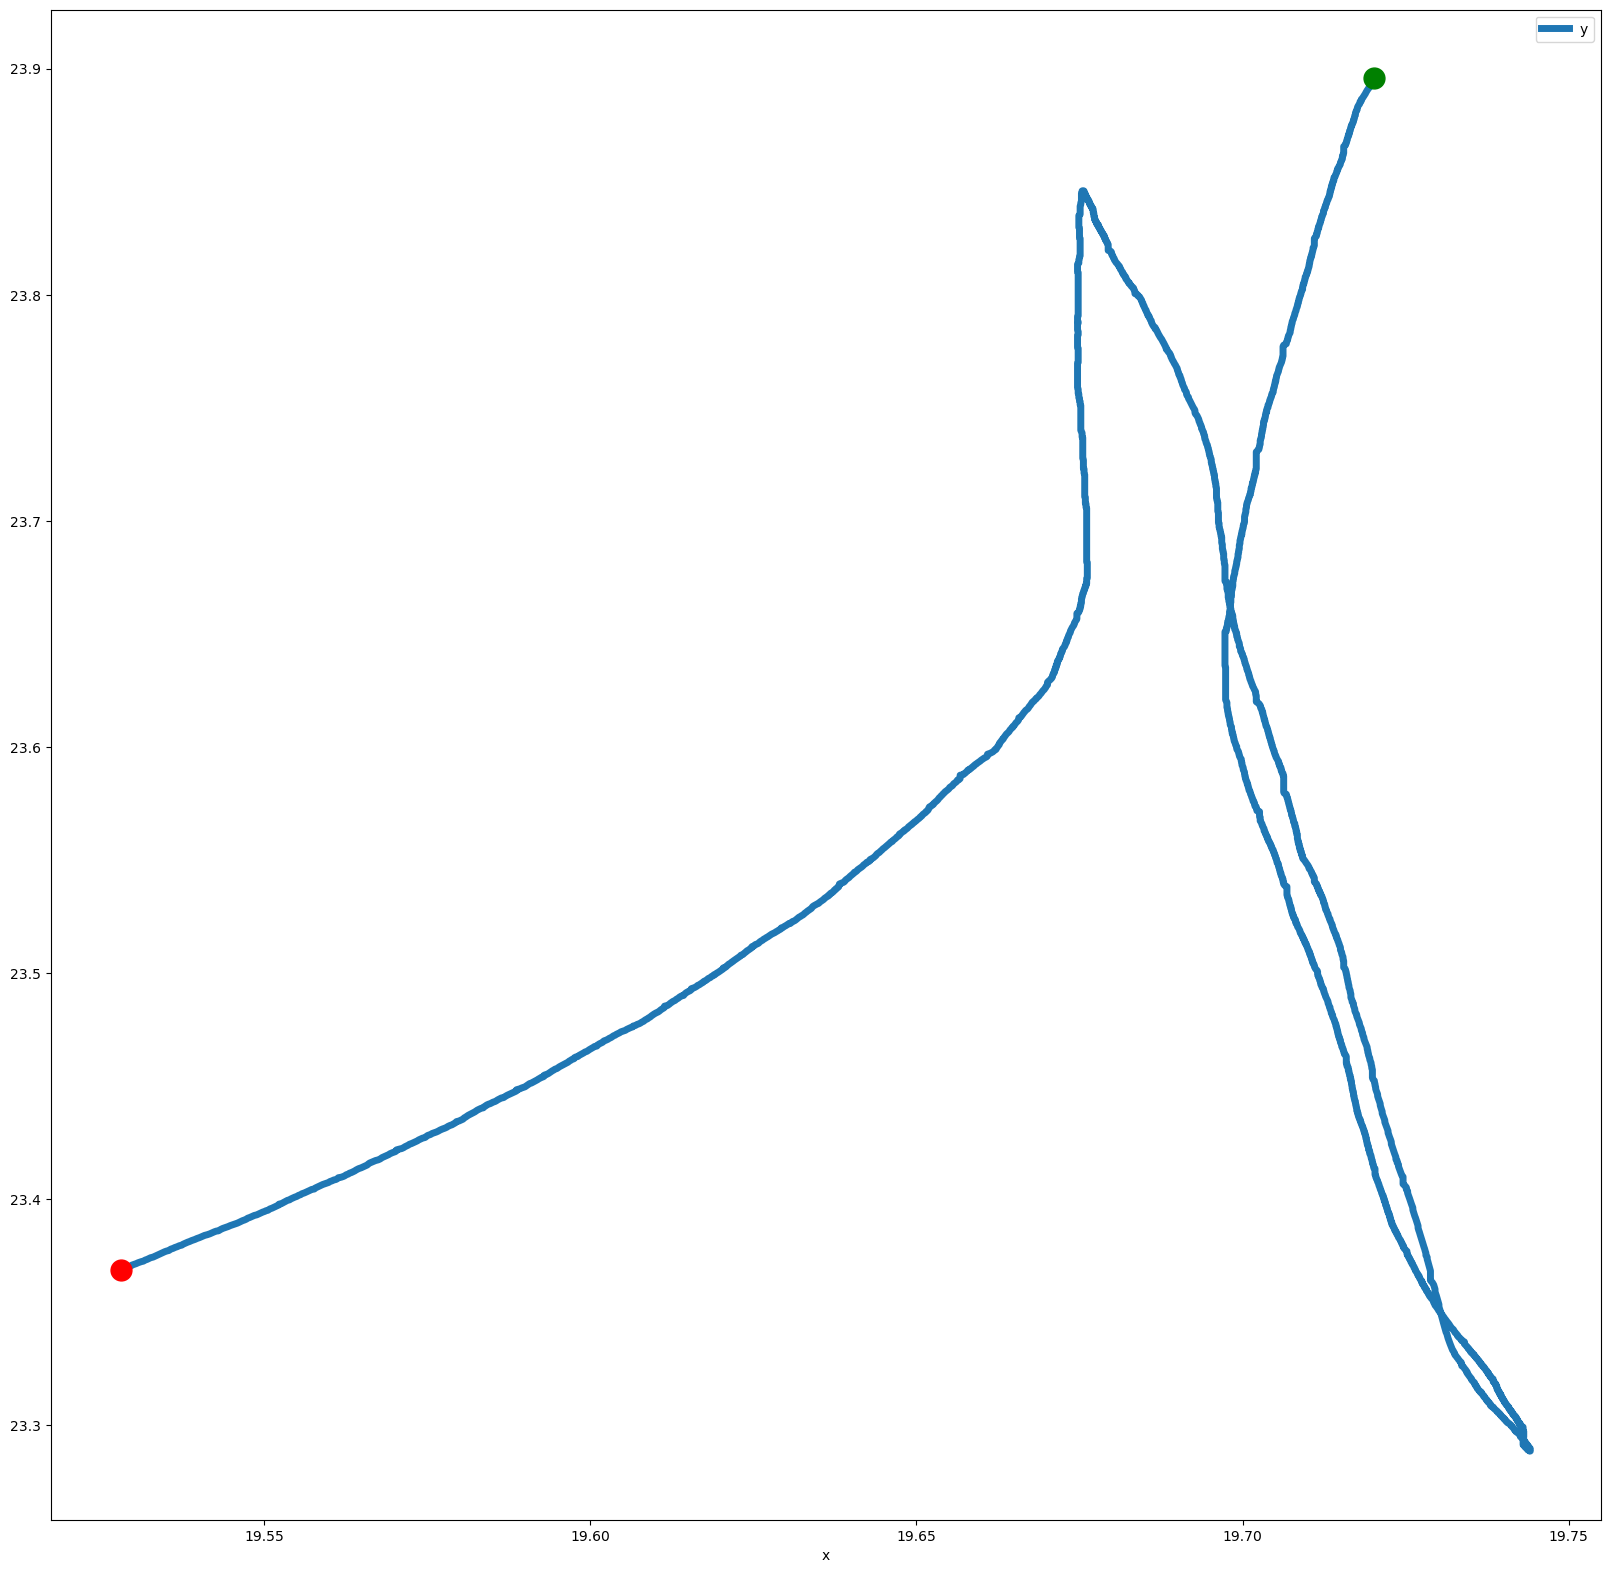

In [116]:
filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_10-10-48_control_worm1-TablePosRecord.txt'
track_df=pd.read_csv(filename)
track_df=track_df.loc[time,:]
ax=track_df.plot(x='x', y='y', linewidth=5, figsize=(20,20))
plt.plot(track_df['x'].head(1),track_df['y'].head(1), 'go', markersize=15)
plt.plot(track_df['x'].tail(1),track_df['y'].tail(1), 'ro', markersize=15)



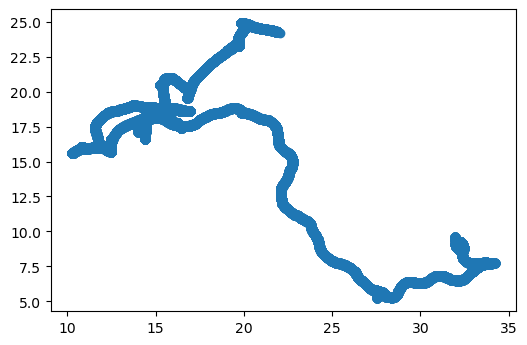

In [81]:
plt.scatter(track_df['x'],track_df['y'])

## Fictive Data

In [133]:
#vector
x = np.array([[2,1], [-1,3], [-2,-2]])
y = np.array([[-1,3], [2,2], [2,2]])
np.cross(x, y)

array([ 7, -8,  0])

In [136]:
#coords
x = np.array([[0,0], [2,1], [1,4],[-1,-2]])
y = np.array([[2,1], [1,4], [-1,-2],[2,3]])
np.cross(x, y)

array([0, 7, 2, 1])

In [132]:
np.dot(x, y)

ValueError: shapes (3,2) and (3,2) not aligned: 2 (dim 1) != 3 (dim 0)

In [125]:
x = np.array([2,-1])
y = np.array([-1,3])
np.cross(x, y)

array(5)

In [126]:
x = np.array([-1,3])
y = np.array([2,2])
np.cross(x, y)

array(-8)

In [127]:
x = np.array([2,2])
y = np.array([-2,-2])
np.cross(x, y)

array(0)

In [128]:
x = np.array([2,2])
y = np.array([-3,-3])
np.cross(x, y)

array(0)

In [ ]:
x = np.array([[0,0], [2,1], [2,2]])
y = np.array([[2,1], [2,2], [-2,-2]])
np.cross(x, y)

## 3D plots

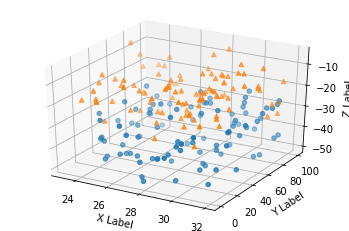

In [17]:
#3D plottingdiffport matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    '''
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    '''
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:

# Import pandas as pd
import pandas as pd

# Read in the CSV file: df
df=principalDf

# Import figure from bokeh.plotting
from bokeh.plotting import figure
from bokeh.io import push_notebook, show, output_notebook 

# Create the figure: p
p = figure(x_axis_label='PC2', y_axis_label='PC3')

# Plot mpg vs hp by color
p.circle(df['PC2'], df['PC3'], size=10)

# Specify the name of the output file and show the result
output_notebook()
show(p)

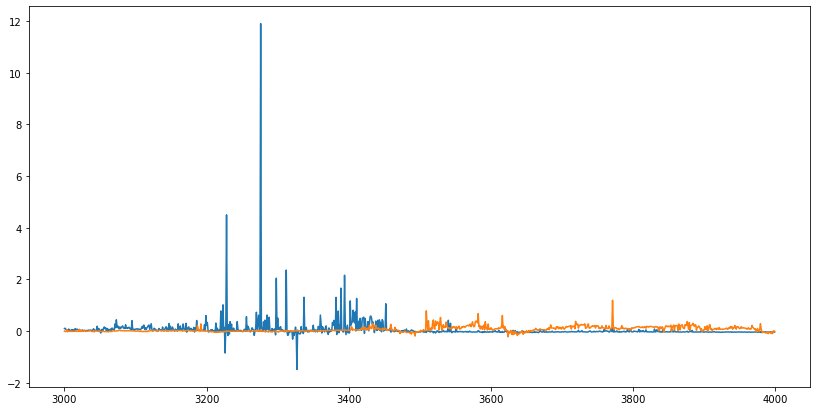

In [12]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [20]:
pca.explained_variance_ratio_

array([0.36016637, 0.16643133, 0.13146125, 0.10535605, 0.07447364])

(-1.0, 1.0)

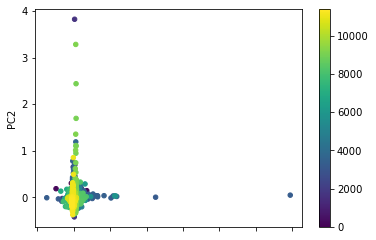

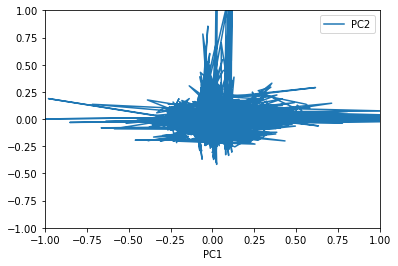

In [13]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [14]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

ValueError: too many values to unpack (expected 2)

<Figure size 504x504 with 0 Axes>

In [ ]:
k,d=principalDf

In [ ]:
d

In [1]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

NameError: name 'plt' is not defined

(-0.2, 0.2)

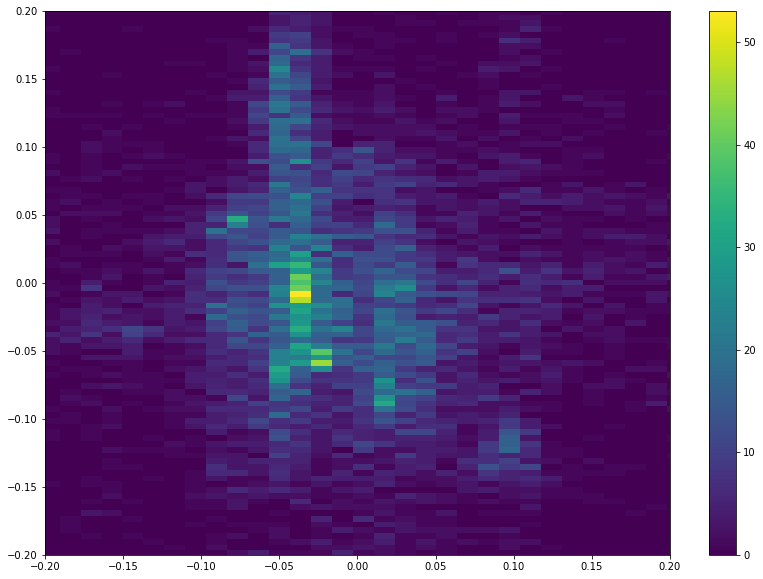

In [16]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

(-0.5, 0.5)

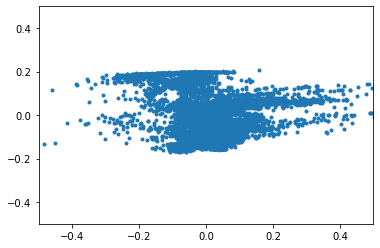

In [17]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

(-0.5, 0.5)

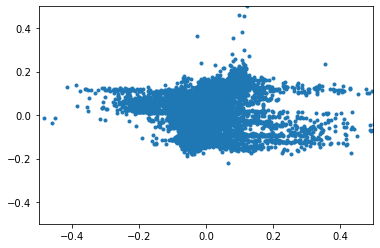

In [18]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [99]:
import re
dir=re.split('-channel',re.split('/',input_filename)[-1])[0]

In [102]:
dir+'_skeleton_X_coords.csv'

'2020-06-05_16-46-41_worm1_skeleton_X_coords.csv'

In [ ]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [ ]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)